# 03 — Feature Engineering
CARE Project — builds the 7,843-point, 9-feature ML training dataset with a 3-class
flood risk label. The rainfall features (Step 7) now come from the 39-year (1987-2025)
HadUK-Grid climatology rather than the original 3-year window — this is the canonical,
current version of the feature matrix.

Pipeline: 01 Data Collection → 02 EDA → **03 Feature Engineering** → 04 ML Model

In [1]:
import os
import glob
import geopandas as gpd
import pandas as pd
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.ops import unary_union
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE            = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
SEPA_PATH       = f"{BASE}/raw/sepa/PVAv2.gpkg"
OSM_BUILD       = f"{BASE}/raw/osm/osm_buildings_glasgow.gpkg"
OSM_ROADS       = f"{BASE}/raw/osm/osm_roads_glasgow.gpkg"
OSM_WATER       = f"{BASE}/raw/osm/osm_water_glasgow.gpkg"
NASA_ELEV       = f"{BASE}/raw/nasa_elevation/nasa_elevation_glasgow.gpkg"
RAIN_ARCHIVE    = f"{BASE}/raw/rainfall"                     # 1987-2025, 467 files (merged)
RAIN_DAILY_PARQUET = f"{BASE}/processed/rainfall_daily_1987_2025.parquet"
RAIN_FEATURES_40YR = f"{BASE}/processed/rainfall_features_40yr.csv"
MAPS_PATH       = f"{BASE}/outputs"
FEATURE_CSV        = f"{BASE}/processed/feature_matrix.csv"             # canonical (40yr)
FEATURE_CSV_COORDS = f"{BASE}/processed/feature_matrix_with_coords.csv" # canonical (40yr) + easting/northing
FEATURE_CSV_40YR   = f"{BASE}/processed/feature_matrix_40yr.csv"        # kept for care_dashboard_step3.py

WET_THRESHOLD_MM = 1.0   # matches the >=1.0mm threshold established in 02_EDA.ipynb

# Study area
UNI_X, UNI_Y, RADIUS = 260983, 665006, 5000
GRID_SPACING = 100
uni_point  = Point(UNI_X, UNI_Y)
uni_buffer = gpd.GeoDataFrame(
    geometry=[uni_point.buffer(RADIUS)], crs="EPSG:27700"
)

print("Paths configured!")
print(f"Study area: {RADIUS/1000}km radius around University of Strathclyde")
print(f"Grid spacing: {GRID_SPACING}m")

Paths configured!
Study area: 5.0km radius around University of Strathclyde
Grid spacing: 100m


## Load supporting datasets (SEPA, buildings, roads, water, elevation)

In [2]:
print("Loading datasets...")

pva        = gpd.read_file(SEPA_PATH)
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(RADIUS))].copy()
buildings  = gpd.read_file(OSM_BUILD)
roads      = gpd.read_file(OSM_ROADS)
water      = gpd.read_file(OSM_WATER)
elevation  = gpd.read_file(NASA_ELEV)

print(f"  SEPA Glasgow:  {len(pva_glasgow)} zones")
print(f"  Buildings:     {len(buildings):,}")
print(f"  Roads:         {len(roads):,}")
print(f"  Water:         {len(water):,}")
print(f"  Elevation:     {len(elevation):,}")
print("\nAll datasets loaded!")

Loading datasets...


  SEPA Glasgow:  7 zones
  Buildings:     55,638
  Roads:         38,218
  Water:         195
  Elevation:     259,200

All datasets loaded!


## Step 1 — Create 100m study grid
Regular grid of points spaced 100m apart covering the 5km circle around the university. Each point becomes one row in the ML training dataset.

In [3]:
# ── Step 1: Create 100m grid ────────────────────────────────
# Regular grid of points spaced 100m apart
# covering the 5km circle around the university
# Each point becomes one row in the ML training dataset

print("Creating 100m grid...")

x_coords = np.arange(UNI_X - RADIUS, UNI_X + RADIUS, GRID_SPACING)
y_coords = np.arange(UNI_Y - RADIUS, UNI_Y + RADIUS, GRID_SPACING)

grid_points = [Point(x, y) for x in x_coords for y in y_coords
               if Point(x, y).distance(uni_point) <= RADIUS]

grid = gpd.GeoDataFrame(
    {'grid_id': range(len(grid_points))},
    geometry=grid_points,
    crs="EPSG:27700"
)

print(f"Grid points created: {len(grid):,}")
print(f"Grid spacing: {GRID_SPACING}m")
print(f"Coverage: {RADIUS/1000}km radius")

Creating 100m grid...
Grid points created: 7,843
Grid spacing: 100m
Coverage: 5.0km radius


## Step 2 — Attach elevation
For each grid point, find the nearest NASA SRTM elevation via spatial nearest-neighbour join.

In [4]:
# ── Step 2: Attach elevation ────────────────────────────────
# For each grid point find the nearest NASA SRTM elevation
# using spatial nearest neighbour join

print("Attaching elevation...")

grid = gpd.sjoin_nearest(
    grid,
    elevation[['elevation', 'geometry']],
    how='left'
).drop(columns=['index_right'])

print(f"Nulls: {grid['elevation'].isnull().sum()}")
print(f"\nElevation stats:")
print(f"  Min:  {grid['elevation'].min():.0f}m")
print(f"  Max:  {grid['elevation'].max():.0f}m")
print(f"  Mean: {grid['elevation'].mean():.1f}m")

Attaching elevation...
Nulls: 0

Elevation stats:
  Min:  -15m
  Max:  127m
  Mean: 42.1m


## Step 3 — Distance to nearest water body
Merge all water polygons into one shape, then compute distance from each grid point to the nearest edge.

In [5]:
# ── Step 3: Distance to nearest water body ──────────────────
# Merge all water polygons into one shape then
# calculate distance from each grid point to nearest edge

print("Calculating distance to water...")

water_union = water.geometry.union_all()
grid['dist_to_water'] = grid.geometry.distance(water_union)

print(f"Nulls: {grid['dist_to_water'].isnull().sum()}")
print(f"\nDistance to water stats:")
print(f"  Min:  {grid['dist_to_water'].min():.1f}m")
print(f"  Max:  {grid['dist_to_water'].max():.1f}m")
print(f"  Mean: {grid['dist_to_water'].mean():.1f}m")

Calculating distance to water...


Nulls: 0

Distance to water stats:
  Min:  0.0m
  Max:  2258.8m
  Mean: 506.7m


## Step 4 — Distance to River Clyde
The River Clyde is the primary flood risk factor in Glasgow — more precise than general distance to water (r=-0.74 vs r=-0.28, per 02_EDA.ipynb).

In [6]:
# ── Step 4: Distance to River Clyde ─────────────────────────
# River Clyde is the primary flood risk factor in Glasgow
# More precise than general distance to water (r=-0.74 vs r=-0.28)

print("Calculating distance to River Clyde...")

clyde = water[water['name'] == 'River Clyde']
clyde_union = clyde.geometry.union_all()

grid['dist_to_clyde'] = grid.geometry.distance(clyde_union)

print(f"Clyde polygons merged: {len(clyde)}")
print(f"Nulls: {grid['dist_to_clyde'].isnull().sum()}")
print(f"\nDistance to Clyde stats:")
print(f"  Min:  {grid['dist_to_clyde'].min():.1f}m")
print(f"  Max:  {grid['dist_to_clyde'].max():.1f}m")
print(f"  Mean: {grid['dist_to_clyde'].mean():.1f}m")

Calculating distance to River Clyde...
Clyde polygons merged: 3
Nulls: 0

Distance to Clyde stats:
  Min:  0.0m
  Max:  6161.5m
  Mean: 2094.6m


## Step 5 — Building count within 250m
High building density implies less natural drainage and higher flood risk.

In [7]:
# ── Step 5: Building count within 250m ─────────────────────
# Count buildings within 250m radius of each grid point
# High density = less natural drainage = higher flood risk

print("Calculating building count (2-3 mins)...")

bld_sindex = buildings.sindex
building_counts = []

for _, row in grid.iterrows():
    buf = row.geometry.buffer(250)
    idx = list(bld_sindex.intersection(buf.bounds))
    matches = buildings.iloc[idx]
    building_counts.append(len(matches[matches.geometry.within(buf)]))

grid['building_count'] = building_counts

print(f"Nulls: {grid['building_count'].isnull().sum()}")
print(f"\nBuilding count stats:")
print(f"  Min:  {grid['building_count'].min()}")
print(f"  Max:  {grid['building_count'].max()}")
print(f"  Mean: {grid['building_count'].mean():.1f}")

Calculating building count (2-3 mins)...


Nulls: 0

Building count stats:
  Min:  0
  Max:  419
  Mean: 92.0


## Step 6 — Road count within 250m
High road density implies more impermeable surface and higher surface-water risk.

In [8]:
# ── Step 6: Road count within 250m ─────────────────────────
# Count road infrastructure nodes within 250m of each grid point
# High density = impermeable surfaces = higher surface water risk

print("Calculating road count (2-3 mins)...")

rd_sindex = roads.sindex
road_counts = []

for _, row in grid.iterrows():
    buf = row.geometry.buffer(250)
    idx = list(rd_sindex.intersection(buf.bounds))
    matches = roads.iloc[idx]
    road_counts.append(len(matches[matches.geometry.within(buf)]))

grid['road_count'] = road_counts

print(f"Nulls: {grid['road_count'].isnull().sum()}")
print(f"\nRoad count stats:")
print(f"  Min:  {grid['road_count'].min()}")
print(f"  Max:  {grid['road_count'].max()}")
print(f"  Mean: {grid['road_count'].mean():.1f}")

Calculating road count (2-3 mins)...


Nulls: 0

Road count stats:
  Min:  0
  Max:  680
  Mean: 60.2


## Step 7a — Extract 39 years of daily rainfall at each grid point (1987-2025)
Reads the merged HadUK-Grid archive (`raw/rainfall/`, 467 files, 1987-2025 — combined from
the two original source batches during the 002_Dataset/ raw-vs-processed reorganisation) into
one continuous daily series. Reuses this notebook's own `grid` GeoDataFrame (built in Step 1)
for the point coordinates, so the nearest-raster-cell lookup is computed once and merges back
onto `grid` by `grid_id` later — no separate grid needs to be rebuilt.

In [9]:
def nearest_indices(coord_array, values):
    diffs = np.abs(coord_array[None, :] - values[:, None])
    return diffs.argmin(axis=1)

def extract_from_file(path, row_idx, col_idx):
    ds = nc.Dataset(path)
    try:
        rainfall = ds.variables["rainfall"][:]  # (time, y, x), masked array
        rainfall = np.ma.filled(rainfall, np.nan)
        t = ds.variables["time"]
        dates = nc.num2date(
            t[:], units=t.units, calendar=t.calendar, only_use_cftime_datetimes=False
        )
        dates = [d.date() for d in dates]
        values = rainfall[:, row_idx, col_idx]  # (n_times, n_points)
    finally:
        ds.close()
    return dates, values

xs = grid.geometry.x.values
ys = grid.geometry.y.values
grid_ids = grid['grid_id'].values
n_points = len(grid)

files = sorted(glob.glob(os.path.join(RAIN_ARCHIVE, "*.nc")))
print(f"Rainfall files to process: {len(files)}")

# raster coordinate grid is identical across all files (confirmed in 01_Data_Collection),
# so nearest-cell indices are computed once from the first file
ref_ds = nc.Dataset(files[0])
proj_x = ref_ds.variables["projection_x_coordinate"][:]
proj_y = ref_ds.variables["projection_y_coordinate"][:]
ref_ds.close()

col_idx = nearest_indices(proj_x, xs)
row_idx = nearest_indices(proj_y, ys)

chunks = []
for i, path in enumerate(files, 1):
    dates, values = extract_from_file(path, row_idx, col_idx)
    n_times = len(dates)
    date_col = np.repeat(dates, n_points)
    grid_col = np.tile(grid_ids, n_times)
    rain_col = values.reshape(-1)
    chunks.append(pd.DataFrame({"grid_id": grid_col, "date": date_col, "rainfall_mm": rain_col}))
    if i % 100 == 0 or i == len(files):
        print(f"[{i}/{len(files)}] {os.path.basename(path)}: {n_times} days")

rainfall_daily = pd.concat(chunks, ignore_index=True)
rainfall_daily["date"] = pd.to_datetime(rainfall_daily["date"])
rainfall_daily = rainfall_daily.sort_values(["date", "grid_id"]).reset_index(drop=True)
rainfall_daily.to_parquet(RAIN_DAILY_PARQUET, index=False)

print("\nDaily rainfall shape:", rainfall_daily.shape)
print(f"Date range: {rainfall_daily['date'].min().date()} to {rainfall_daily['date'].max().date()}")
print(f"Saved to {RAIN_DAILY_PARQUET}")

Rainfall files to process: 467


[100/467] rainfall_hadukgrid_uk_5km_day_19950401-19950430.nc: 30 days


[200/467] rainfall_hadukgrid_uk_5km_day_20030801-20030831.nc: 31 days


[300/467] rainfall_hadukgrid_uk_5km_day_20111201-20111231.nc: 31 days


[400/467] rainfall_hadukgrid_uk_5km_day_20200401-20200430.nc: 30 days


[467/467] rainfall_hadukgrid_uk_5km_day_20251201-20251231.nc: 31 days



Daily rainfall shape: (111480402, 3)
Date range: 1987-01-01 to 2025-12-31
Saved to /Users/riteshghorpade/Documents/010_Project/002_Dataset/processed/rainfall_daily_1987_2025.parquet


## Step 7b — Aggregate to 4 climatology features
`mean_annual_mm_day` and `mean_winter_mm_day` (Dec/Jan/Feb) are simple means; `wet_days_per_year`
uses the ≥1.0mm threshold established in 02_EDA.ipynb, averaged per calendar year;
`max_daily_mm` is the average of each year's maximum (not a single 39-year max), so one
extreme year doesn't dominate a "typical annual peak" feature.

In [10]:
rainfall_daily["year"] = rainfall_daily["date"].dt.year
rainfall_daily["month"] = rainfall_daily["date"].dt.month

mean_annual = rainfall_daily.groupby("grid_id")["rainfall_mm"].mean().rename("mean_annual_mm_day")

winter = rainfall_daily[rainfall_daily["month"].isin([12, 1, 2])]
mean_winter = winter.groupby("grid_id")["rainfall_mm"].mean().rename("mean_winter_mm_day")

rainfall_daily["wet"] = rainfall_daily["rainfall_mm"] >= WET_THRESHOLD_MM
wet_per_year = rainfall_daily.groupby(["grid_id", "year"])["wet"].sum()
wet_days_per_year = wet_per_year.groupby("grid_id").mean().rename("wet_days_per_year")

yearly_max = rainfall_daily.groupby(["grid_id", "year"])["rainfall_mm"].max()
max_daily_mm = yearly_max.groupby("grid_id").mean().rename("max_daily_mm")

rainfall_features = pd.concat(
    [mean_annual, mean_winter, wet_days_per_year, max_daily_mm], axis=1
).reset_index()
rainfall_features.to_csv(RAIN_FEATURES_40YR, index=False)

print("Rainfall features shape:", rainfall_features.shape)
print(rainfall_features.head())

Rainfall features shape: (7843, 5)
   grid_id  mean_annual_mm_day  mean_winter_mm_day  wet_days_per_year  \
0        0            3.022107            3.723017         172.717949   
1        1            2.944663            3.715277         166.717949   
2        2            2.944663            3.715277         166.717949   
3        3            2.944663            3.715277         166.717949   
4        4            2.944663            3.715277         166.717949   

   max_daily_mm  
0     32.273127  
1     33.308127  
2     33.308127  
3     33.308127  
4     33.308127  


## Step 7c — Attach the 39-year rainfall features to the grid
Direct merge on `grid_id` (replaces the old lat/lon `sjoin_nearest` against a 4-cell
`rain_gdf`) — safe because `rainfall_features` was computed on this exact `grid`'s own
points, so every `grid_id` already lines up.

In [11]:
print("Attaching rainfall features...")

grid = grid.merge(rainfall_features, on="grid_id", how="left")

print(f"Nulls: {grid[['mean_annual_mm_day','wet_days_per_year']].isnull().sum().sum()}")
print(f"\nRainfall stats:")
print(f"  Annual mean: {grid['mean_annual_mm_day'].min():.3f} to {grid['mean_annual_mm_day'].max():.3f} mm/day")
print(f"  Wet days:    {grid['wet_days_per_year'].min():.0f} to {grid['wet_days_per_year'].max():.0f} days/year")

Attaching rainfall features...
Nulls: 0

Rainfall stats:
  Annual mean: 2.705 to 3.080 mm/day
  Wet days:    165 to 176 days/year


## Step 8 — Create flood risk label
Combines SEPA PVA zones with elevation into 3 classes: High (2) inside PVA & elevation ≤15m,
Medium (1) inside PVA & elevation ≤35m, Low (0) otherwise.

In [12]:
# ── Step 8: Create flood risk label ─────────────────────────
# Combines SEPA PVA zones with elevation to create 3 classes:
# High   (2): Inside PVA AND elevation <= 15m
# Medium (1): Inside PVA AND elevation <= 35m
# Low    (0): Outside PVA OR elevation > 35m

print("Creating flood risk labels...")

# Spatial join — which grid points are inside PVA zones
grid_labelled = gpd.sjoin(
    grid,
    pva_glasgow[['PVA_Name', 'geometry']],
    how='left',
    predicate='within'
)
grid_labelled['inside_pva'] = grid_labelled['PVA_Name'].notna().astype(int)

# Remove duplicates from spatial join
grid_labelled = grid_labelled.drop_duplicates(subset='grid_id').reset_index(drop=True)

# Assign 3-class label
def assign_risk(row):
    if row['inside_pva'] == 1 and row['elevation'] <= 15:
        return 2  # High risk
    elif row['inside_pva'] == 1 and row['elevation'] <= 35:
        return 1  # Medium risk
    else:
        return 0  # Low risk

grid_labelled['flood_risk'] = grid_labelled.apply(assign_risk, axis=1)

print(f"Total points: {len(grid_labelled):,}")
print(f"\nClass distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (grid_labelled['flood_risk']==cls).sum()
    pct   = count/len(grid_labelled)*100
    print(f"  {name} risk (Class {cls}): {count:,} ({pct:.1f}%)")
    

Creating flood risk labels...
Total points: 7,843

Class distribution:
  Low risk (Class 0): 3,790 (48.3%)
  Medium risk (Class 1): 2,698 (34.4%)
  High risk (Class 2): 1,355 (17.3%)


## Step 9 — Export feature matrix
Selects the 9 ML features + label, adds `easting`/`northing` from the grid geometry for
dashboard mapping, and writes the canonical `feature_matrix.csv` (now 40yr rainfall) plus
`feature_matrix_with_coords.csv` and `feature_matrix_40yr.csv` (kept for
`care_dashboard_step3.py`).

In [13]:
feature_cols = [
    'elevation', 'dist_to_water', 'dist_to_clyde', 'building_count', 'road_count',
    'mean_annual_mm_day', 'mean_winter_mm_day', 'wet_days_per_year', 'max_daily_mm',
    'flood_risk'
]

feature_matrix = grid_labelled[feature_cols].copy().reset_index(drop=True)
feature_matrix['easting'] = grid_labelled.geometry.x.values
feature_matrix['northing'] = grid_labelled.geometry.y.values

print("Null check:")
print(feature_matrix.isnull().sum())

feature_matrix.drop(columns=['easting', 'northing']).to_csv(FEATURE_CSV, index=False)
feature_matrix.to_csv(FEATURE_CSV_COORDS, index=False)
feature_matrix.to_csv(FEATURE_CSV_40YR, index=False)

print(f"\nFeature matrix saved!")
print(f"Shape: {feature_matrix.shape}")
print(f"Paths: {FEATURE_CSV}, {FEATURE_CSV_COORDS}, {FEATURE_CSV_40YR}")
print(f"\nFirst 5 rows:")
print(feature_matrix.head())

Null check:
elevation             0
dist_to_water         0
dist_to_clyde         0
building_count        0
road_count            0
mean_annual_mm_day    0
mean_winter_mm_day    0
wet_days_per_year     0
max_daily_mm          0
flood_risk            0
easting               0
northing              0
dtype: int64

Feature matrix saved!
Shape: (7843, 12)
Paths: /Users/riteshghorpade/Documents/010_Project/002_Dataset/processed/feature_matrix.csv, /Users/riteshghorpade/Documents/010_Project/002_Dataset/processed/feature_matrix_with_coords.csv, /Users/riteshghorpade/Documents/010_Project/002_Dataset/processed/feature_matrix_40yr.csv

First 5 rows:
   elevation  dist_to_water  dist_to_clyde  building_count  road_count  \
0          8     429.130538     429.130538              62          57   
1         17     808.615363    1228.448457              42          58   
2         14     724.363088    1135.327775              38          73   
3         13     644.627770    1043.142726            

## Step 10 — Feature matrix summary statistics

In [14]:
print("=" * 55)
print("FEATURE MATRIX SUMMARY")
print("=" * 55)
print(f"\nTotal grid points: {len(feature_matrix):,}")
print(f"Total features:    {len(feature_cols)-1}")
print(f"\nFeature statistics:")
print(feature_matrix[feature_cols[:-1]].describe().round(2))

print(f"\nClass distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (feature_matrix['flood_risk']==cls).sum()
    pct   = count/len(feature_matrix)*100
    bar   = '█' * int(pct/2)
    print(f"  Class {cls} ({name}): {count:,} ({pct:.1f}%) {bar}")

print(f"\nCorrelation with flood_risk:")
corr = feature_matrix[feature_cols].corr()['flood_risk'].drop('flood_risk').sort_values()
for feat, val in corr.items():
    direction = "lower=more risk" if val < 0 else "higher=more risk"
    print(f"  {feat:<22} {val:>7.3f}  {direction}")

FEATURE MATRIX SUMMARY

Total grid points: 7,843
Total features:    9

Feature statistics:
       elevation  dist_to_water  dist_to_clyde  building_count  road_count  \
count    7843.00        7843.00        7843.00         7843.00     7843.00   
mean       42.10         506.69        2094.60           92.03       60.19   
std        27.47         368.36        1566.94           77.84       61.67   
min       -15.00           0.00           0.00            0.00        0.00   
25%        20.00         221.60         776.37           28.00       22.00   
50%        33.00         447.21        1784.42           75.00       42.00   
75%        63.00         724.45        3179.09          140.00       79.00   
max       127.00        2258.81        6161.51          419.00      680.00   

       mean_annual_mm_day  mean_winter_mm_day  wet_days_per_year  max_daily_mm  
count             7843.00             7843.00            7843.00       7843.00  
mean                 2.96                3.6

## Step 11 — Feature matrix visualisation
Same 6-panel summary as before, but the rainfall panel (bottom-right) is now computed
dynamically from the actual per-grid-cell `wet_days_per_year` values instead of the old
hardcoded 3-year, 4-cell numbers — the 39-year data touches a different number of raster
cells, so hardcoding would silently show stale figures.

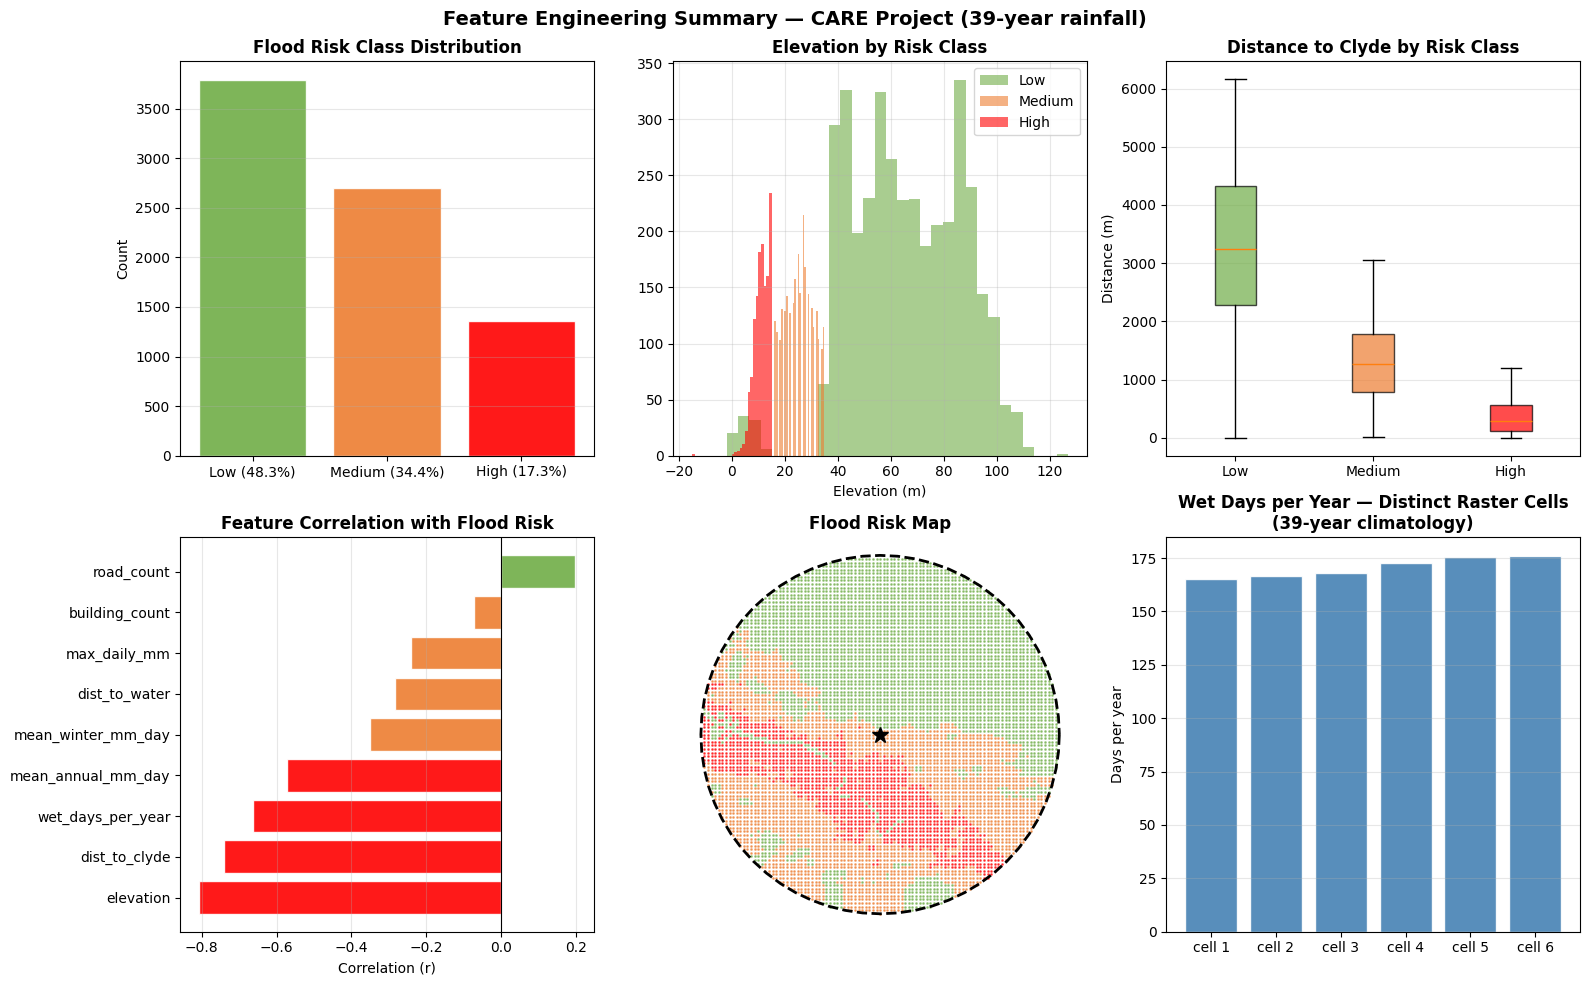

Summary saved!


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

colors = ['#70AD47', '#ED7D31', '#FF0000']

# 1. Risk class distribution
class_counts = feature_matrix['flood_risk'].value_counts().sort_index()
class_labels = [f"{n} ({class_counts[c]/len(feature_matrix)*100:.1f}%)"
                for c, n in zip([0,1,2], ['Low','Medium','High'])]
axes[0,0].bar(class_labels, class_counts.values, color=colors, edgecolor='white', alpha=0.9)
axes[0,0].set_title("Flood Risk Class Distribution", fontweight='bold')
axes[0,0].set_ylabel("Count")
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Elevation distribution by class
for cls, color, name in zip([0,1,2], colors, ['Low','Medium','High']):
    data = feature_matrix[feature_matrix['flood_risk']==cls]['elevation']
    axes[0,1].hist(data, bins=30, alpha=0.6, color=color, label=name)
axes[0,1].set_title("Elevation by Risk Class", fontweight='bold')
axes[0,1].set_xlabel("Elevation (m)")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Distance to Clyde by class
data_cls = [feature_matrix[feature_matrix['flood_risk']==c]['dist_to_clyde'].values
            for c in [0,1,2]]
bp = axes[0,2].boxplot(data_cls, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0,2].set_xticklabels(['Low','Medium','High'])
axes[0,2].set_title("Distance to Clyde by Risk Class", fontweight='bold')
axes[0,2].set_ylabel("Distance (m)")
axes[0,2].grid(axis='y', alpha=0.3)

# 4. Correlation bar chart
corr = feature_matrix[feature_cols].corr()['flood_risk'].drop('flood_risk').sort_values()
colors_corr = ['#FF0000' if v < -0.5 else '#ED7D31' if v < 0 else '#70AD47'
               for v in corr.values]
axes[1,0].barh(corr.index, corr.values, color=colors_corr, edgecolor='white', alpha=0.9)
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_title("Feature Correlation with Flood Risk", fontweight='bold')
axes[1,0].set_xlabel("Correlation (r)")
axes[1,0].grid(axis='x', alpha=0.3)

# 5. Risk map
risk_colors = {0:'#70AD47', 1:'#ED7D31', 2:'#FF0000'}
for cls, color in risk_colors.items():
    subset = grid_labelled[grid_labelled['flood_risk']==cls]
    subset.plot(ax=axes[1,1], color=color, markersize=1, alpha=0.6)
uni_buffer.plot(ax=axes[1,1], color='none', edgecolor='black', linewidth=2, linestyle='--')
axes[1,1].plot(UNI_X, UNI_Y, marker='*', color='black', markersize=12)
axes[1,1].set_title("Flood Risk Map", fontweight='bold')
axes[1,1].axis('off')

# 6. Rainfall spatial variation — computed dynamically from actual data, not hardcoded
distinct_wet_day_values = sorted(feature_matrix['wet_days_per_year'].unique())
axes[1,2].bar(
    [f"cell {i+1}" for i in range(len(distinct_wet_day_values))],
    distinct_wet_day_values,
    color='steelblue', edgecolor='white', alpha=0.9
)
axes[1,2].set_title("Wet Days per Year — Distinct Raster Cells\n(39-year climatology)", fontweight='bold')
axes[1,2].set_ylabel("Days per year")
axes[1,2].grid(axis='y', alpha=0.3)

plt.suptitle("Feature Engineering Summary — CARE Project (39-year rainfall)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/feature_engineering_summary.png", dpi=150)
plt.show()
print("Summary saved!")